In [60]:
import pandas as pd
import numpy as np

df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [61]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [62]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [63]:
df.isnull().sum()

missing_values = df.isnull().sum()
if missing_values.any() > 0:
    print("Columns with missing values:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found.")


Columns with missing values:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [64]:
df.sort_values(by="Order").head(10)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
5,6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
6,7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
7,8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
8,9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500
9,10,527162130,60,RL,60.0,7500,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,189000


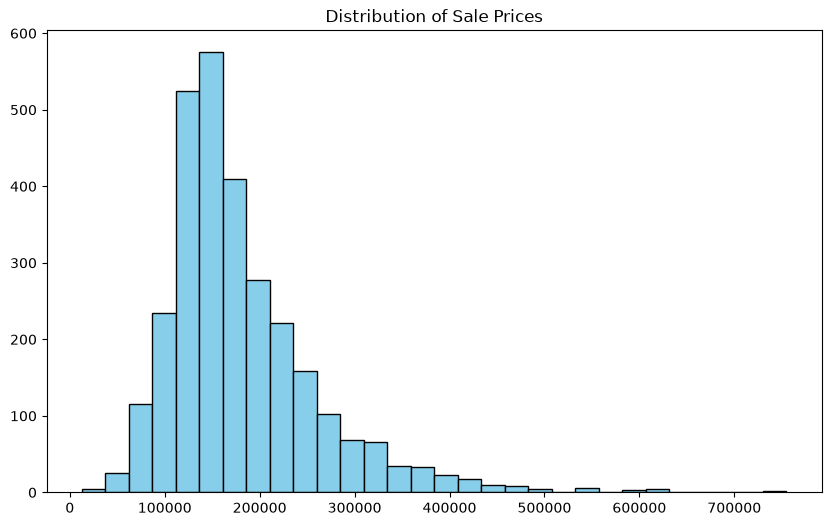

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["SalePrice"], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Sale Prices")
plt.show()


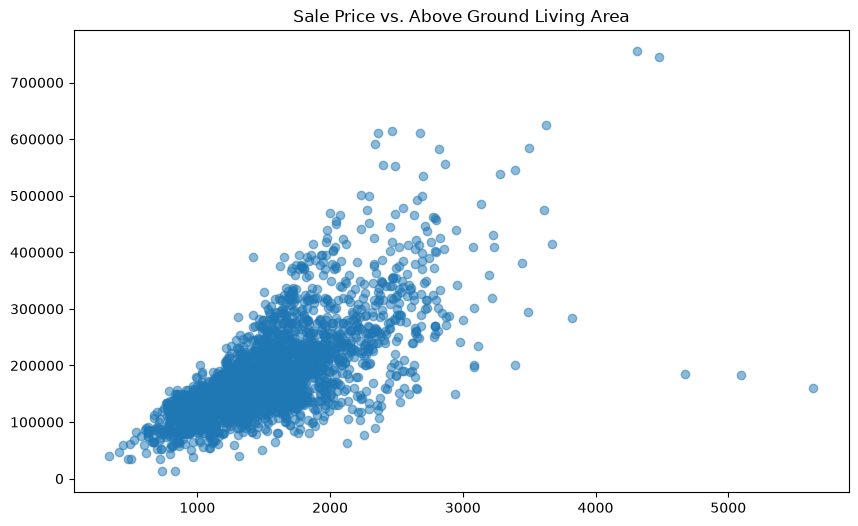

In [66]:
import matplotlib.pyplot as plt

x= df["Gr Liv Area"]
y= df["SalePrice"]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5)
plt.title("Sale Price vs. Above Ground Living Area")
plt.show()

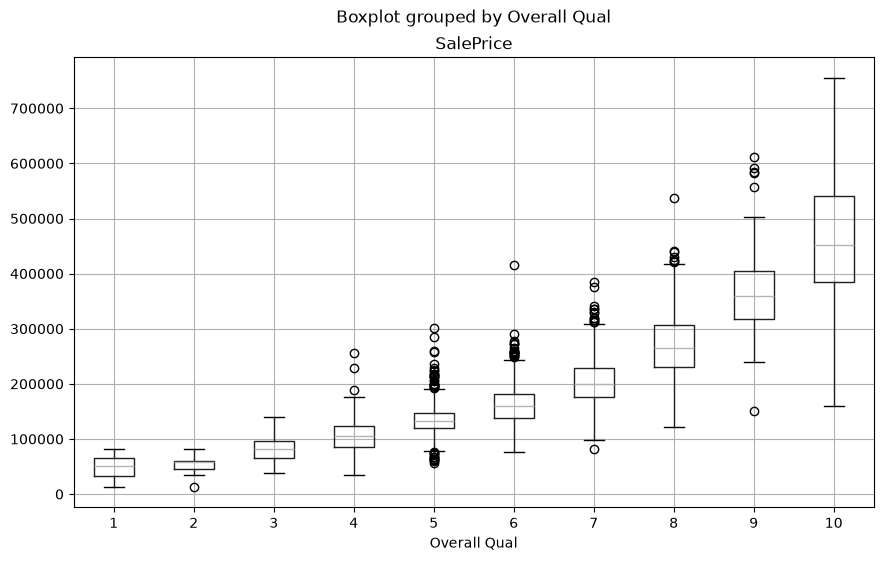

In [67]:
import matplotlib.pyplot as plt

df.boxplot(
    column="SalePrice",
    by="Overall Qual",
    figsize=(10, 6)
)
plt.show()

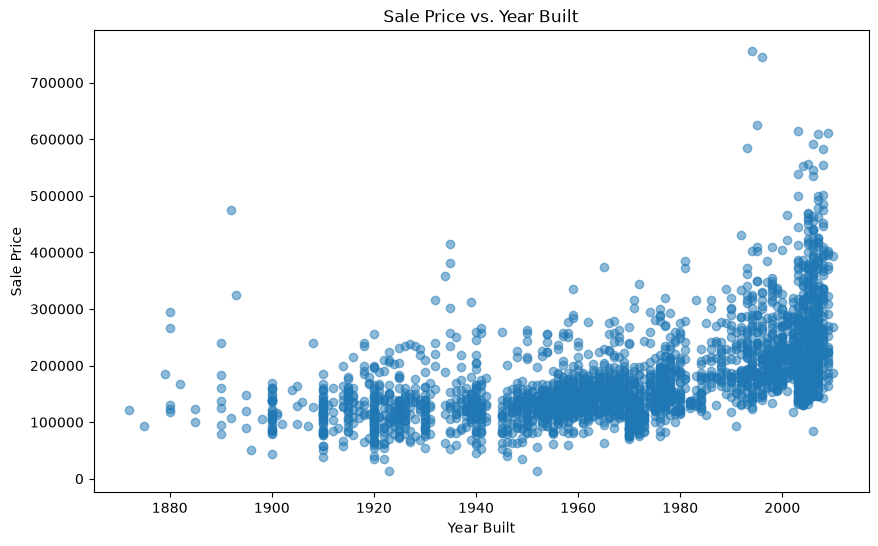

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df["Year Built"], df["SalePrice"], alpha=0.5)
plt.title("Sale Price vs. Year Built")
plt.xlabel("Year Built")
plt.ylabel("Sale Price")
plt.show()


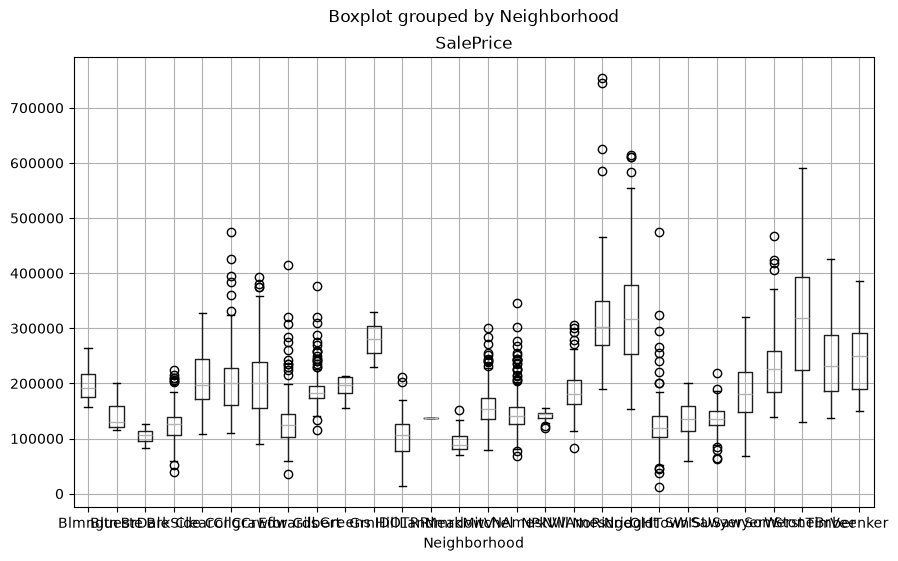

In [69]:
df.boxplot(
    column="SalePrice",
    by="Neighborhood",
    figsize=(10, 6)
)

plt.show()

In [70]:
import pandas as pd
x = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

print("x shape:", x.shape)
print("y shape:", y.shape)

x.head()


x shape: (2930, 81)
y shape: (2930,)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2344, 81)
X_test: (586, 81)
y_train: (2344,)
y_test: (586,)


In [72]:

numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

if "MS SubClass" in numeric_columns:
    numeric_columns.remove("MS SubClass")
    categorical_columns.append("MS SubClass")

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Order', 'PID', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold']

Categorical columns:
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central

C:\Users\maher\AppData\Local\Temp\ipykernel_40772\2151623603.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(


In [73]:
from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(strategy="median")

X_train_numeric = numeric_imputer.fit_transform(
    X_train[numeric_columns]
)

X_test_numeric = numeric_imputer.transform(
    X_test[numeric_columns]
)

print("Training numeric shape:", X_train_numeric.shape)
print("Test numeric shape:", X_test_numeric.shape)

Training numeric shape: (2344, 37)
Test numeric shape: (586, 37)


In [74]:
absence_columns = [
    "Alley",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Pool QC",
    "Fence",
    "Misc Feature"
]

In [75]:
absence_columns = [
    col for col in absence_columns
    if col in categorical_columns
]

In [76]:
from sklearn.impute import SimpleImputer

absence_imputer = SimpleImputer(
    strategy="constant",
    fill_value="None"
)

X_train_absence = absence_imputer.fit_transform(
    X_train[absence_columns]
)

X_test_absence = absence_imputer.transform(
    X_test[absence_columns]
)

print("Train absence shape:", X_train_absence.shape)
print("Test absence shape:", X_test_absence.shape)

Train absence shape: (2344, 14)
Test absence shape: (586, 14)


In [77]:
other_categorical_columns = [
    col for col in categorical_columns
    if col not in absence_columns
]

categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_categorical = categorical_imputer.fit_transform(
    X_train[other_categorical_columns]
)

X_test_categorical = categorical_imputer.transform(
    X_test[other_categorical_columns]
)

print("Train categorical shape:", X_train_categorical.shape)
print("Test categorical shape:", X_test_categorical.shape)

Train categorical shape: (2344, 30)
Test categorical shape: (586, 30)


In [78]:
from sklearn.preprocessing import OneHotEncoder

absence_encoder = OneHotEncoder(handle_unknown="ignore")
categorical_encoder = OneHotEncoder(handle_unknown="ignore")

X_train_absence_encoded = absence_encoder.fit_transform(
    X_train_absence
)

X_test_absence_encoded = absence_encoder.transform(
    X_test_absence
)

X_train_categorical_encoded = categorical_encoder.fit_transform(
    X_train_categorical
)

X_test_categorical_encoded = categorical_encoder.transform(
    X_test_categorical
)

print("Encoded absence train:", X_train_absence_encoded.shape)
print("Encoded categorical train:", X_train_categorical_encoded.shape)

Encoded absence train: (2344, 78)
Encoded categorical train: (2344, 216)


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric_scaled = scaler.fit_transform(
    X_train_numeric
)

X_test_numeric_scaled = scaler.transform(
    X_test_numeric
)

print("Scaled numeric train:", X_train_numeric_scaled.shape)
print("Scaled numeric test:", X_test_numeric_scaled.shape)

Scaled numeric train: (2344, 37)
Scaled numeric test: (586, 37)


In [80]:
from scipy.sparse import hstack

X_train_prepared = hstack([
    X_train_numeric_scaled,
    X_train_absence_encoded,
    X_train_categorical_encoded
])

X_test_prepared = hstack([
    X_test_numeric_scaled,
    X_test_absence_encoded,
    X_test_categorical_encoded
])

print("Final training shape:", X_train_prepared.shape)
print("Final test shape:", X_test_prepared.shape)

Final training shape: (2344, 331)
Final test shape: (586, 331)


In [81]:
X_train = X_train.drop(
    columns=["Order", "PID"],
    errors="ignore"
)

X_test = X_test.drop(
    columns=["Order", "PID"],
    errors="ignore"
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("Features used before encoding:", X_train.shape[1])
print("Final features after preprocessing:", X_train_prepared.shape[1])

X_train shape: (2344, 79)
X_test shape: (586, 79)
Features used before encoding: 79
Final features after preprocessing: 331


In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train_prepared,
    y_train
)

print("Linear Regression trained successfully")

Linear Regression trained successfully


In [83]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(
    X_train_prepared,
    y_train
)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [85]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    random_state=42
)

forest_model.fit(
    X_train_prepared,
    y_train
)

print("Random Forest trained successfully")

Random Forest trained successfully


In [87]:
linear_predictions = linear_model.predict(X_test_prepared)

tree_predictions = tree_model.predict(X_test_prepared)

forest_predictions = forest_model.predict(X_test_prepared)

In [88]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("Linear Regression:")
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

print("\nDecision Tree:")
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

print("\nRandom Forest:")
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

Linear Regression:
RMSE: 29261.014719882874
R²: 0.893208373705318

Decision Tree:
RMSE: 35315.81935190782
R²: 0.8444403317267881

Random Forest:
RMSE: 26503.487004751772
R²: 0.9123878236258308


In [90]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],
    "Test RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "Test R²": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results

,Model,Test RMSE,Test R²
0,Linear Regression,29261.014720,0.893208
1,Decision Tree Regression,35315.819352,0.844440
2,Random Forest Regression,26503.487005,0.912388
